In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/bank-churn-dataset/Churn_Modelling.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (10000, 14)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

=== Missing Values ===
RowNumber          0
CustomerId         0
Su

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Columns after dropping irrelevant ones: {list(df.columns)}")

Columns after dropping irrelevant ones: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [6]:
print("Missing values per column:")
print(df.isnull().sum())

# Fill numeric missing values with median (robust to outliers)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Filled missing values in '{col}' with median")

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values per column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Missing values after handling:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
print("Categorical columns:", df.select_dtypes(include='object').columns.tolist())

# One-hot encode Geography (France, Spain, Germany -> 3 binary columns)
df = pd.get_dummies(df, columns=['Geography'], drop_first=False)

# Binary encode Gender (Male=1, Female=0)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

print(f"\nDataset shape after encoding: {df.shape}")
print(f"New columns: {list(df.columns)}")

Categorical columns: ['Geography', 'Gender']

Dataset shape after encoding: (10000, 13)
New columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


=== Class Distribution ===
  Not Churned (0): 7963  (79.6%)
  Churned     (1): 2037  (20.4%)


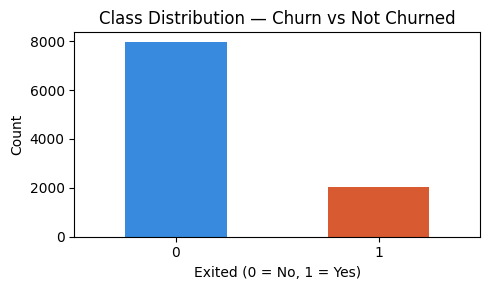

Plot saved to report/


In [9]:
churn_counts = df['Exited'].value_counts()
churn_pct    = df['Exited'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(f"  Not Churned (0): {churn_counts[0]}  ({churn_pct[0]:.1f}%)")
print(f"  Churned     (1): {churn_counts[1]}  ({churn_pct[1]:.1f}%)")

# Visualise
plt.figure(figsize=(5, 3))
churn_counts.plot(kind='bar', color=['#378ADD', '#D85A30'], edgecolor='none')
plt.title('Class Distribution — Churn vs Not Churned')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bank-churn-dataset/class_distribution.png', dpi=150)
plt.show()
print("Plot saved to report/")

In [10]:
X = df.drop(columns=['Exited'])
y = df['Exited']

print(f"Features (X) shape: {X.shape}")
print(f"Target  (y) shape:  {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")


Features (X) shape: (10000, 12)
Target  (y) shape:  (10000,)

Feature columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,       # fixed seed = reproducible results
    stratify=y             # preserve class imbalance ratio
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nChurn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")

Training set:  8000 rows
Test set:      2000 rows

Churn rate in train: 20.4%
Churn rate in test:  20.3%


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames so column names are preserved
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Scaling complete.")
print(f"\nSample means after scaling (should be ~0):")
print(X_train_scaled.mean().round(6).head(5))

Scaling complete.

Sample means after scaling (should be ~0):
CreditScore   -0.0
Gender         0.0
Age            0.0
Tenure        -0.0
Balance        0.0
dtype: float64


In [14]:
X_train_scaled.to_csv('/content/drive/MyDrive/bank-churn-dataset/dataX_train.csv', index=False)
X_test_scaled.to_csv('/content/drive/MyDrive/bank-churn-dataset/data/X_test.csv',   index=False)
y_train.to_csv('/content/drive/MyDrive/bank-churn-dataset/data/y_train.csv',         index=False)
y_test.to_csv('/content/drive/MyDrive/bank-churn-dataset/data/y_test.csv',           index=False)

print("Processed data saved to data/ folder:")
print("  X_train.csv, X_test.csv, y_train.csv, y_test.csv")


Processed data saved to data/ folder:
  X_train.csv, X_test.csv, y_train.csv, y_test.csv


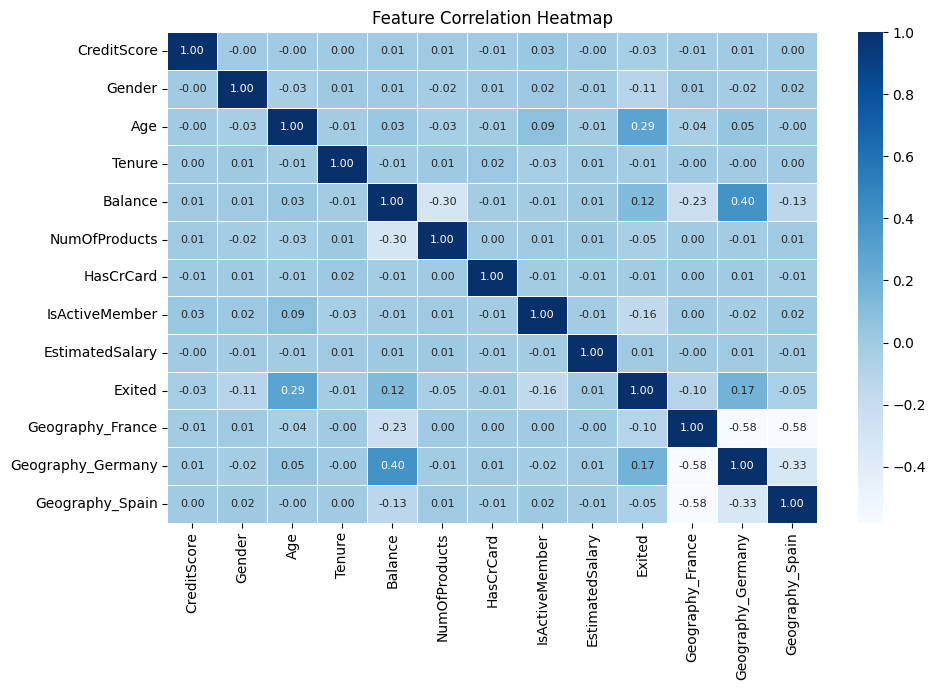

Heatmap saved to report/

=== Preprocessing Complete ===
All other members can now load X_train.csv / X_test.csv


In [16]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bank-churn-dataset/report/correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved to report/")

print("\n=== Preprocessing Complete ===")
print("All other members can now load X_train.csv / X_test.csv")
